In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle


import warnings
warnings.filterwarnings('ignore')

In [2]:
#laoding dataset

df = pd.read_csv('/content/loan_data.csv')

In [3]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [4]:
df.shape

(9578, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [6]:
# checking for the missing values
df.isnull().sum()

,0
credit.policy,0
purpose,0
int.rate,0
installment,0
log.annual.inc,0
dti,0
fico,0
days.with.cr.line,0
revol.bal,0
revol.util,0


In [7]:
#checking for the duplicates values in the dataset
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='object')

# Exploratory data Analysis

In [9]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


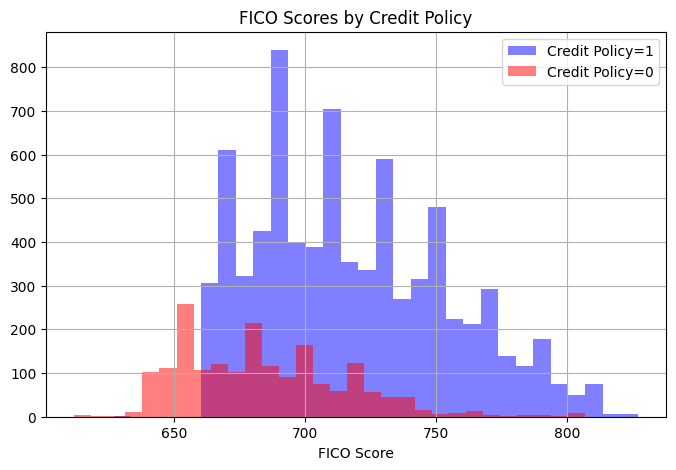

In [10]:
# Histogram of FICO scores by credit.policy
plt.figure(figsize=(8,5))
df[df['credit.policy']==1]['fico'].hist(alpha=0.5, color='blue', bins=30, label='Credit Policy=1')
df[df['credit.policy']==0]['fico'].hist(alpha=0.5, color='red', bins=30, label='Credit Policy=0')
plt.legend()
plt.xlabel('FICO Score')
plt.title('FICO Scores by Credit Policy')
plt.show()


**This plot shows credit scores (FICO) distribution for borrowers who meet vs don’t meet the bank’s lending policy.**

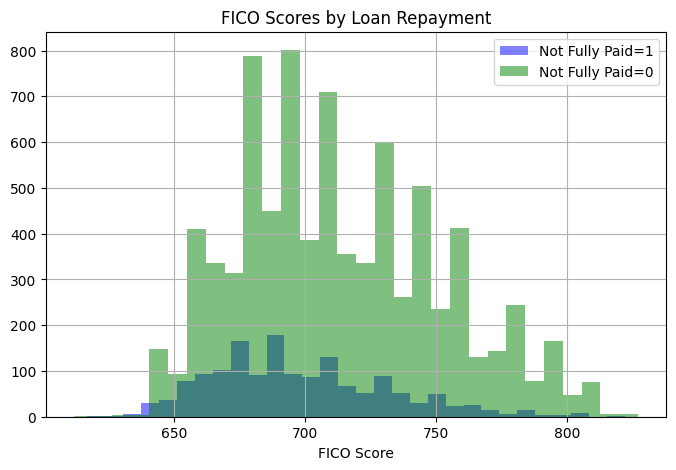

In [11]:
# Histogram of FICO scores by not.fully.paid
plt.figure(figsize=(8,5))
df[df['not.fully.paid']==1]['fico'].hist(alpha=0.5, color='blue', bins=30, label='Not Fully Paid=1')
df[df['not.fully.paid']==0]['fico'].hist(alpha=0.5, color='green', bins=30, label='Not Fully Paid=0')
plt.legend()
plt.xlabel('FICO Score')
plt.title('FICO Scores by Loan Repayment')
plt.show()

**Compares FICO scores of borrowers who defaulted (not.fully.paid=1) vs those who repaid.**

In [12]:
df['not.fully.paid'].value_counts()

,count
not.fully.paid,
0,8045
1,1533


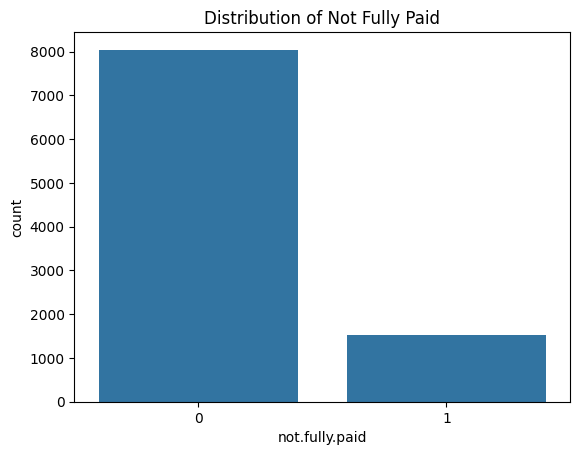

In [13]:
#plotting the distribution of the not fully paid column

sns.countplot(x='not.fully.paid', data=df)
plt.title('Distribution of Not Fully Paid')
plt.show()

**Dataset is imbalanced**

In [14]:
df_corr = df.drop(['purpose'], axis=1)

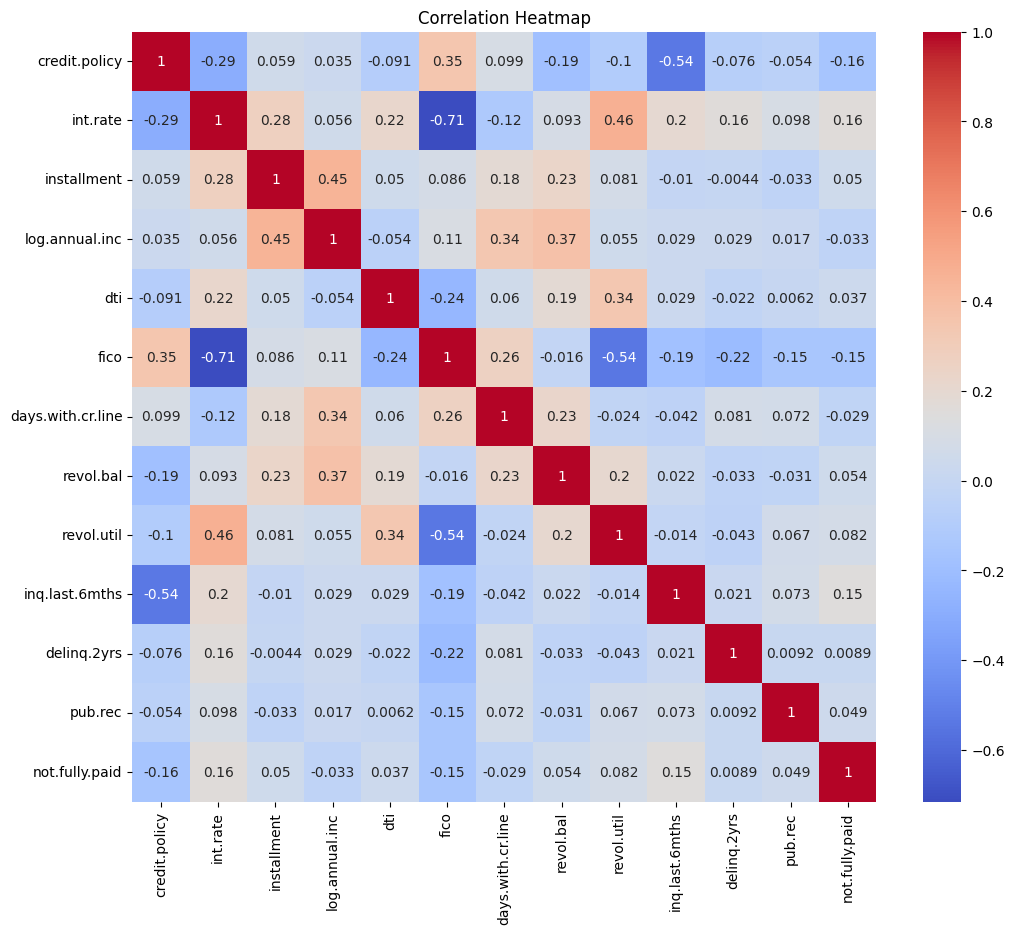

In [15]:
# correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

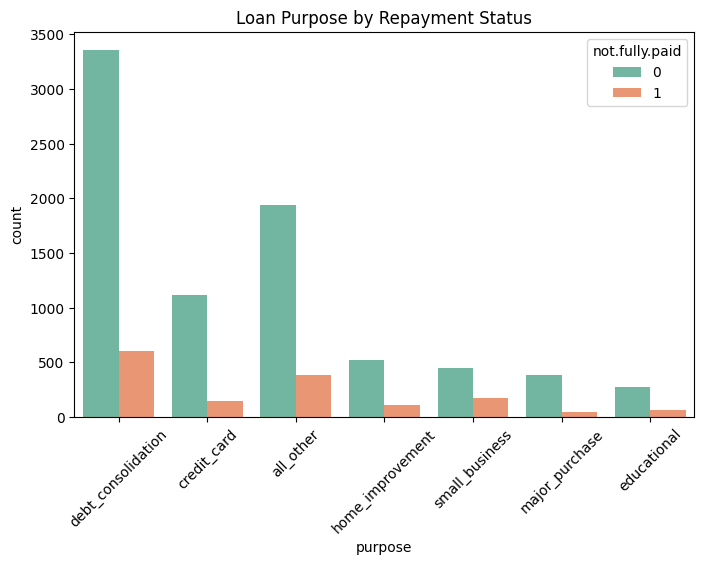

In [16]:
# Countplot of loans by purpose
plt.figure(figsize=(8,5))
sns.countplot(x='purpose', hue='not.fully.paid', data=df, palette='Set2')
plt.title('Loan Purpose by Repayment Status')
plt.xticks(rotation=45)
plt.show()

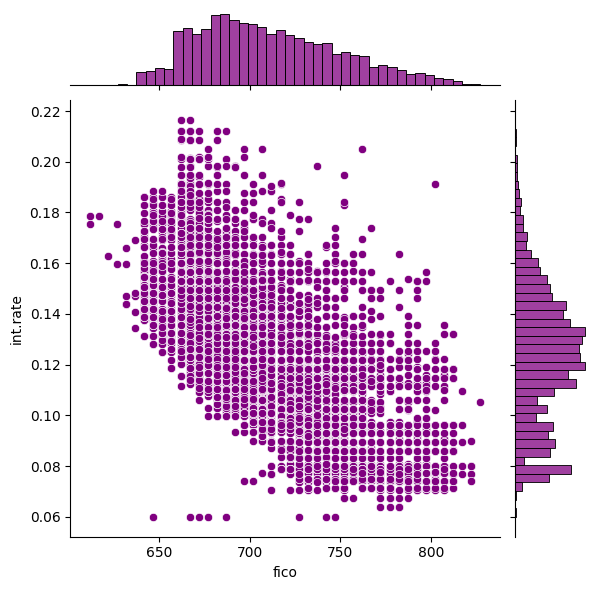

In [17]:
# Jointplot of FICO score vs interest rate
sns.jointplot(x='fico', y='int.rate', data=df, color='purple')
plt.show()


* Scatter + histogram plot showing relationship between FICO and interest rate.

* Higher FICO → lower interest rate (inverse relationship).

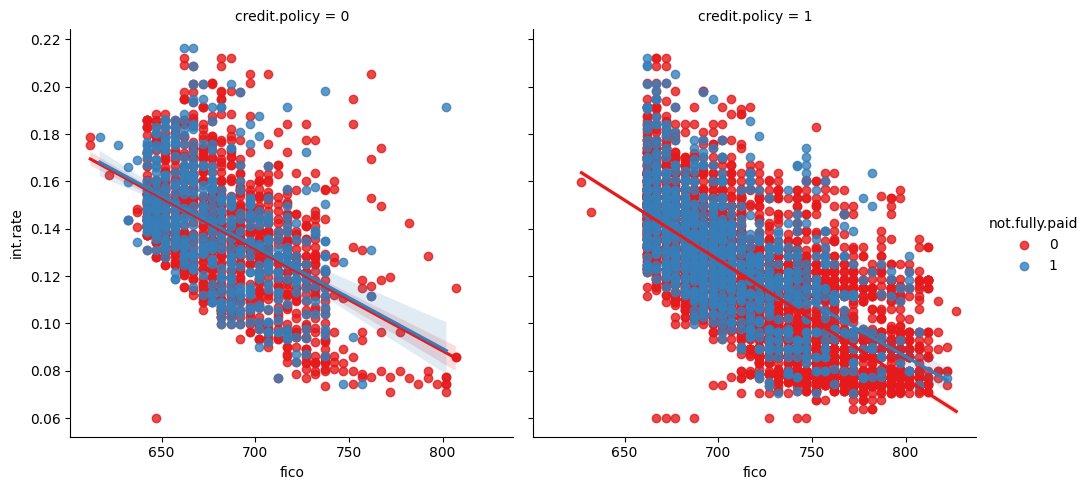

In [18]:
# lmplot of interest rate vs fico
sns.lmplot(x='fico', y='int.rate', data=df, hue='not.fully.paid', col='credit.policy', palette='Set1')
plt.show()


**Regression plots split by repayment status and credit policy.**

# Data Preprocessing

In [19]:
# Convert categorical 'purpose' into dummy variables
df = pd.get_dummies(df, columns=['purpose'], drop_first=True)



In [20]:
df.shape

(9578, 19)

In [21]:
df.columns

Index(['credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti',
       'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid',
       'purpose_credit_card', 'purpose_debt_consolidation',
       'purpose_educational', 'purpose_home_improvement',
       'purpose_major_purchase', 'purpose_small_business'],
      dtype='object')

In [22]:
# Define features and target
X = df.drop('not.fully.paid', axis=1)
y = df['not.fully.paid']

# Train Test Spliting

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [24]:
# after spliting shape of the training dataset and testing dataset
print("Shape of the X_train is: ", X_train.shape)
print("Shape of the X_test is: ",X_test.shape)
print("Shape of the y_train is: ",y_train.shape)
print("Shape of the y_test is: ",y_test.shape)

Shape of the X_train is:  (6704, 18)
Shape of the X_test is:  (2874, 18)
Shape of the y_train is:  (6704,)
Shape of the y_test is:  (2874,)


# Model Training

In [25]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=101)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=101)

In [26]:
y_pred = dt_model.predict(X_test)


In [27]:
# checking the accuracy of the model

Accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of the model is: ", Accuracy)

Accuracy of the model is:  0.7359081419624217


**Accuracy of the model is low because of the data imbalanced**

In [28]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.84      2408
           1       0.20      0.21      0.20       466

    accuracy                           0.74      2874
   macro avg       0.52      0.52      0.52      2874
weighted avg       0.74      0.74      0.74      2874



<Axes: >

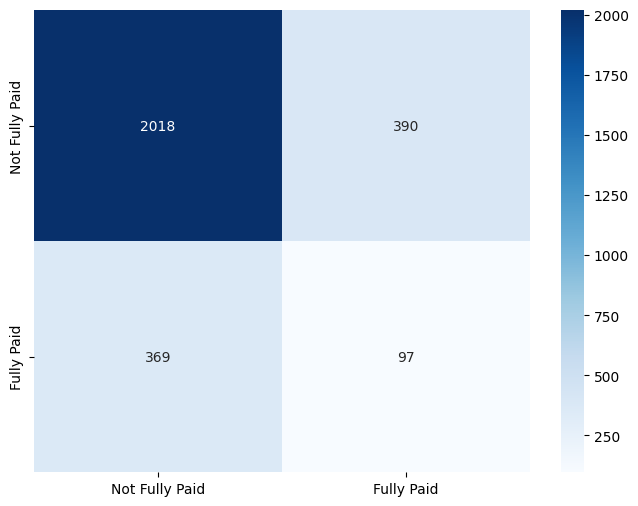

In [29]:
# ploting the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fully Paid', 'Fully Paid'], yticklabels=['Not Fully Paid', 'Fully Paid'])

## Training Random forest Model

In [30]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=300, random_state=101)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=101)

In [31]:
rf_preds = rf_model.predict(X_test)

In [32]:
rf_accuracy = accuracy_score(y_test, rf_preds)
print("Accuracy of the Random Forest Model is: ", rf_accuracy)

Accuracy of the Random Forest Model is:  0.8361169102296451


In [33]:
print("\nClassification Report:\n", classification_report(y_test, rf_preds))


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.99      0.91      2408
           1       0.39      0.02      0.04       466

    accuracy                           0.84      2874
   macro avg       0.62      0.51      0.47      2874
weighted avg       0.77      0.84      0.77      2874



<Axes: >

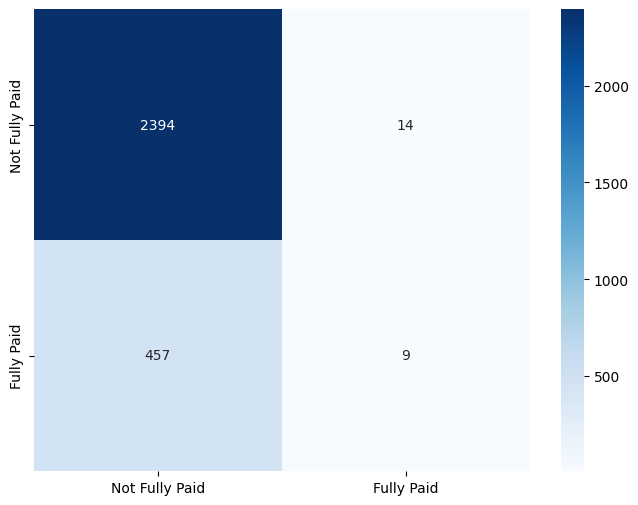

In [34]:
# confusion matrix
rf_cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fully Paid', 'Fully Paid'], yticklabels=['Not Fully Paid', 'Fully Paid'])

# Handling Imbalanced dataset

In [35]:
from sklearn.utils import resample

df_majority = df[df['not.fully.paid'] == 0]   # fully repaid
df_minority = df[df['not.fully.paid'] == 1]   # not fully repaid

In [36]:
# showing the distribution of the class with the percentage
print("Class Distribution:")
print(df['not.fully.paid'].value_counts(normalize=True))


Class Distribution:
not.fully.paid
0    0.839946
1    0.160054
Name: proportion, dtype: float64


In [37]:
df_majority_downsampled = resample(df_majority,
                                   replace=False,     # sample without replacement
                                   n_samples=len(df_minority), # match minority count
                                   random_state=101)

In [38]:
# Combine minority and downsampled majority

df_balanced = pd.concat([df_majority_downsampled, df_minority])


In [39]:
print("\nBalanced Class Distribution:")
print(df_balanced['not.fully.paid'].value_counts())


Balanced Class Distribution:
not.fully.paid
0    1533
1    1533
Name: count, dtype: int64


# Balanced dataset Train Test split

In [40]:
X = df_balanced.drop('not.fully.paid', axis=1)
y = df_balanced['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [41]:
print("Shape of the X_train is: ", X_train.shape)
print("Shape of the X_test is: ",X_test.shape)
print("Shape of the y_train is: ",y_train.shape)
print("Shape of the y_test is: ",y_test.shape)

Shape of the X_train is:  (2146, 18)
Shape of the X_test is:  (920, 18)
Shape of the y_train is:  (2146,)
Shape of the y_test is:  (920,)


In [42]:
dt_model_2 = DecisionTreeClassifier(random_state=101)
dt_model_2.fit(X_train, y_train)


DecisionTreeClassifier(random_state=101)

In [43]:
dt_preds = dt_model_2.predict(X_test)

In [44]:
Accuracy_dt = accuracy_score(y_test, dt_preds)
print("Accuracy of the Decision Tree Model is: ", Accuracy_dt)

Accuracy of the Decision Tree Model is:  0.5423913043478261


In [45]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=101)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("Accuracy of the Random Forest Model is: ", accuracy_score(y_test, rf_preds))

Accuracy of the Random Forest Model is:  0.6173913043478261


**Down Sampling is not working fine so let me apply up sampling on this dataset.**

# SMOTE Technique for This dataset

In [46]:
from imblearn.over_sampling import SMOTE

X_smote = df.drop('not.fully.paid', axis=1)
y_smote = df['not.fully.paid']

In [47]:
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(X_smote, y_smote, test_size=0.3, random_state=101, stratify=y_smote)

In [48]:
smote = SMOTE(random_state=101)
X_train_res, y_train_res = smote.fit_resample(X_train_smote, y_train_smote)

In [49]:
print("\nBalanced Training Class Distribution:")
print(y_train_res.value_counts())


Balanced Training Class Distribution:
not.fully.paid
0    5631
1    5631
Name: count, dtype: int64


# Model training on Smote dataset

In [50]:
dt_model_smote = DecisionTreeClassifier(random_state=101)
dt_model_smote.fit(X_train_res, y_train_res)


DecisionTreeClassifier(random_state=101)

In [51]:
dt_preds_smote = dt_model_smote.predict(X_test_smote)

In [52]:
print("Accuracy of the Decision Tree Model is: ", accuracy_score(y_test_smote, dt_preds_smote))

Accuracy of the Decision Tree Model is:  0.6757132915796799


In [53]:
# classification report
print("\nClassification Report:\n", classification_report(y_test_smote, dt_preds_smote))


Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.75      0.79      2414
           1       0.19      0.30      0.23       460

    accuracy                           0.68      2874
   macro avg       0.52      0.53      0.51      2874
weighted avg       0.74      0.68      0.70      2874



<Axes: >

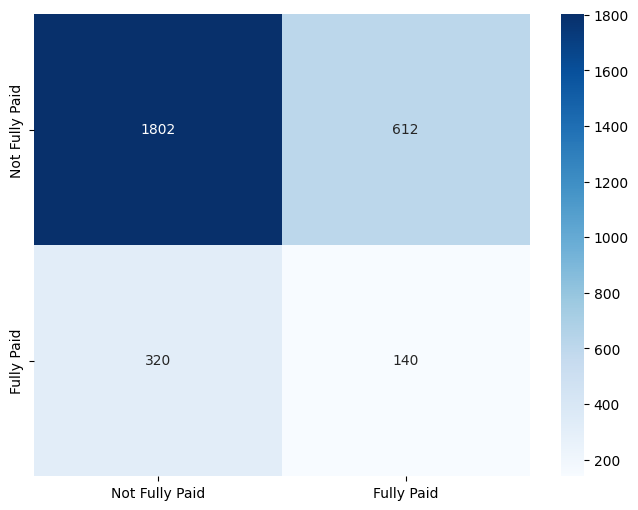

In [54]:
# confussion matrix
cm_smote = confusion_matrix(y_test_smote, dt_preds_smote)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fully Paid', 'Fully Paid'], yticklabels=['Not Fully Paid', 'Fully Paid'])

In [55]:
#random Forest Implementation

rf_model_smote = RandomForestClassifier(n_estimators=300, random_state=101)
rf_model_smote.fit(X_train_res, y_train_res)
rf_preds_smote = rf_model_smote.predict(X_test_smote)

In [56]:
print("Accuracy of the Random Forest Model is: ", accuracy_score(y_test_smote, rf_preds_smote))

Accuracy of the Random Forest Model is:  0.767571329157968


In [57]:
print("\nClassification Report:\n", classification_report(y_test_smote, rf_preds_smote))


Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86      2414
           1       0.24      0.21      0.23       460

    accuracy                           0.77      2874
   macro avg       0.55      0.54      0.55      2874
weighted avg       0.76      0.77      0.76      2874



<Axes: >

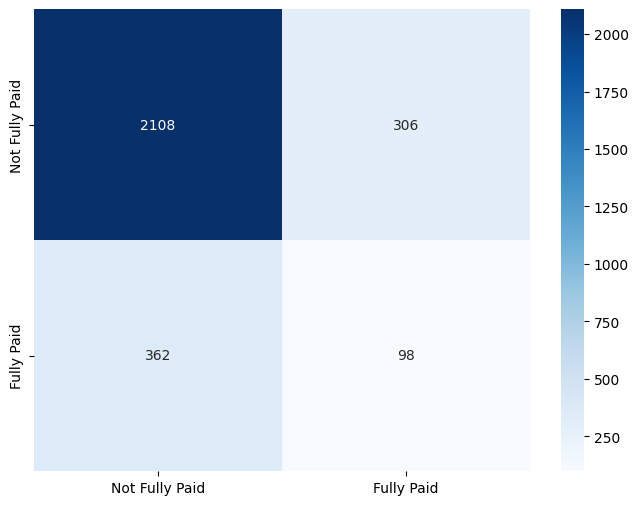

In [58]:
# confussion matrix for random forest
cm_rf_smote = confusion_matrix(y_test_smote, rf_preds_smote)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_smote, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fully Paid', 'Fully Paid'], yticklabels=['Not Fully Paid', 'Fully Paid'])

# Class weight Balanced Technique


In [59]:
rf_model_bal = RandomForestClassifier(
    n_estimators=300,
    random_state=101,
    class_weight='balanced'   # <-- Important
)
rf_model_bal.fit(X_train, y_train)
rf_preds_bal = rf_model_bal.predict(X_test)


In [60]:
print("Accuracy of the Random Forest Model by using the Class weight balanced is: ", accuracy_score(y_test, rf_preds_bal))

Accuracy of the Random Forest Model by using the Class weight balanced is:  0.6260869565217392


In [61]:
print("\nClassification Report:\n", classification_report(y_test, rf_preds_bal))


Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.62      0.62       461
           1       0.62      0.63      0.63       459

    accuracy                           0.63       920
   macro avg       0.63      0.63      0.63       920
weighted avg       0.63      0.63      0.63       920



# Feature Importance

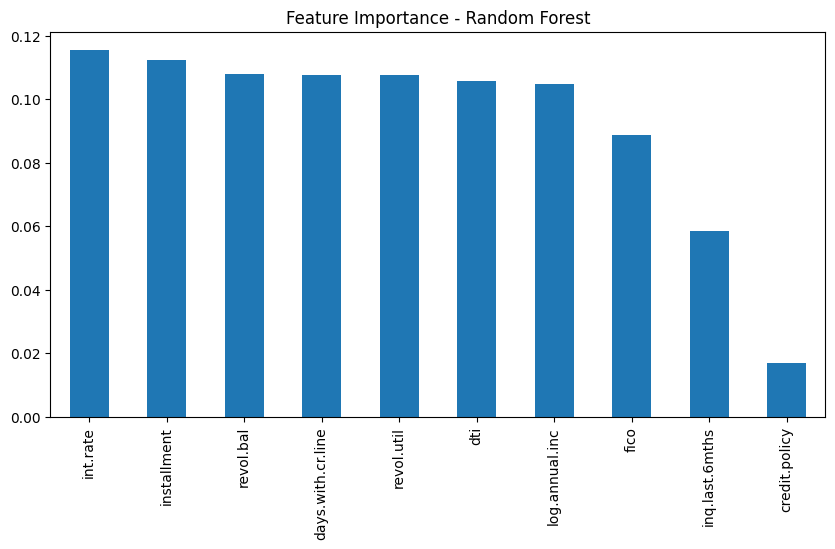

In [62]:
importances = rf_model_bal.feature_importances_
feat_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feat_importances[:10].plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance - Random Forest")
plt.show()


# 5 Fold Cross Validation for the Random Forest

In [63]:
from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(rf_model_bal, X, y, cv=5, scoring='accuracy')
print("Mean Accuracy:", cv_scores.mean())
print("Std Deviation:", cv_scores.std())


Mean Accuracy: 0.4970822196598137
Std Deviation: 0.05615167202600341


# Model Saving For Future use

In [64]:
with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf_model_bal, f)